In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
# Load Datasets and info
df = pd.read_csv("/kaggle/input/datasets/nudratabbas/software-developer-salary-prediction-dataset/train.csv")
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 5 rows')
print(df.head())
print('\nTypes of Data:')
print(df.dtypes)

Shape: (40000, 7)

Columns: ['experience', 'country', 'education', 'languages', 'frameworks', 'company_size', 'salary_usd']

First 5 rows
   experience  country     education         languages             frameworks  \
0          34  Germany       Masters  Rust, JavaScript           Vue, ASP.NET   
1           9       UK       Masters    C#, JavaScript  Ruby on Rails, Spring   
2           8      USA  Some College           C++, Go             Vue, React   
3          29      USA       Masters         C++, Ruby        Spring, Angular   
4           7      USA     Bachelors          C#, Rust         React, Express   

  company_size  salary_usd  
0     201-1000      172292  
1     201-1000       82311  
2        5000+      109637  
3        11-50      214386  
4         1-10      107584  

Types of Data:
experience       int64
country         object
education       object
languages       object
frameworks      object
company_size    object
salary_usd       int64
dtype: object


In [9]:
# Checking any Missing values and basic stats
print('Missing Values')
print(df.isnull().sum())

print('\nDuplicates:', df.duplicated().sum())

print('\nSalary Stats:')
print(df['salary_usd'].describe())

print('\nUnique Values per Column:')
for col in df.columns:
    print(f"{col} : {df[col].nunique()} unique values")

Missing Values
experience      0
country         0
education       0
languages       0
frameworks      0
company_size    0
salary_usd      0
dtype: int64

Duplicates: 0

Salary Stats:
count     40000.000000
mean     131834.441525
std       46426.249810
min       12024.000000
25%       98172.250000
50%      130579.000000
75%      164431.000000
max      277554.000000
Name: salary_usd, dtype: float64

Unique Values per Column:
experience : 41 unique values
country : 10 unique values
education : 5 unique values
languages : 100 unique values
frameworks : 100 unique values
company_size : 6 unique values
salary_usd : 35646 unique values


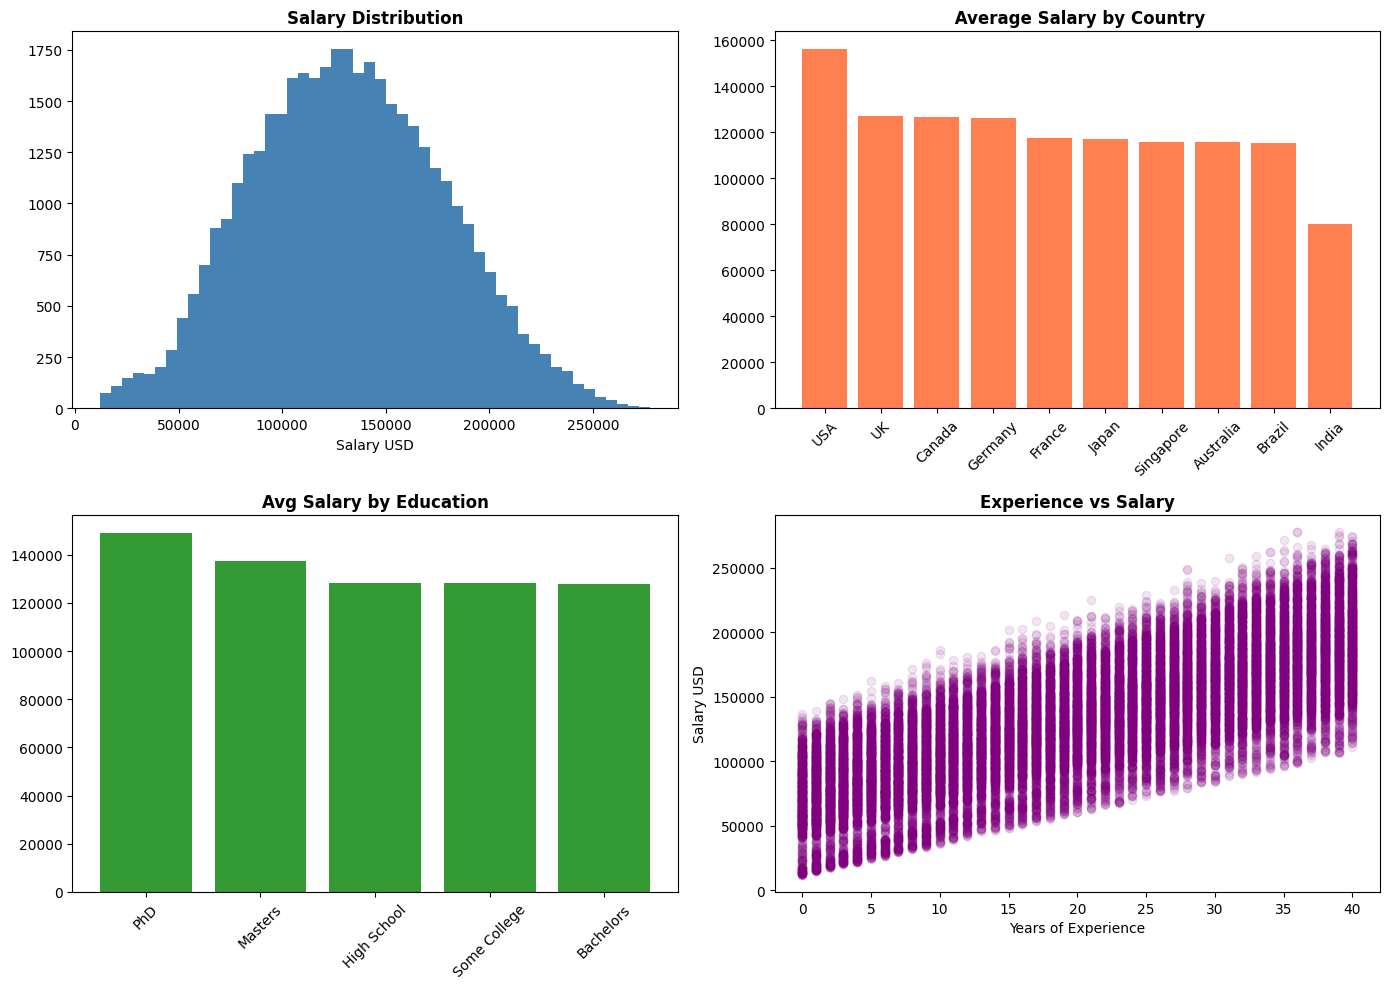

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Chart 1 - Salary Distribution
axes[0,0].hist(df['salary_usd'], bins=50, color='steelblue')
axes[0,0].set_title('Salary Distribution', fontweight='bold')
axes[0,0].set_xlabel('Salary USD')

# Chart 2 - Average Salary by Country
country_salary = df.groupby('country')['salary_usd'].mean().sort_values(ascending=False)
axes[0,1].bar(country_salary.index, country_salary.values, color='coral')
axes[0,1].set_title(' Average Salary by Country', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)

# Chart 3 — Avg Salary by Education
edu_salary = df.groupby('education')['salary_usd'].mean().sort_values(ascending=False)
axes[1,0].bar(edu_salary.index, edu_salary.values, color='green', alpha=0.8)
axes[1,0].set_title('Avg Salary by Education', fontweight='bold')
axes[1,0].tick_params(axis='x', rotation=45)

# Chart 4 — Experience vs Salary
axes[1,1].scatter(df['experience'], df['salary_usd'], alpha=0.1, color='purple')
axes[1,1].set_title('Experience vs Salary', fontweight='bold')
axes[1,1].set_xlabel('Years of Experience')
axes[1,1].set_ylabel('Salary USD')

plt.tight_layout()
plt.show()

# Quick Insights from Charts  
Chart 1 — Salary Distribution  
	∙	Normal bell curve — most earn USD100K-USD160K  
	∙	Few very low or very high outliers  
Chart 2 — Country  
    ∙	USA pays most (USD155K)  
	∙	India pays least (USD75K)  
	∙	Big gap between USA and everyone else  
Chart 3 — Education  
	∙	PhD earns most  
	∙	But gap is small — experience matters more!  
Chart 4 — Experience  
	∙	Clear upward trend — more experience = more salary  
	∙	Strong positive correlation ✅

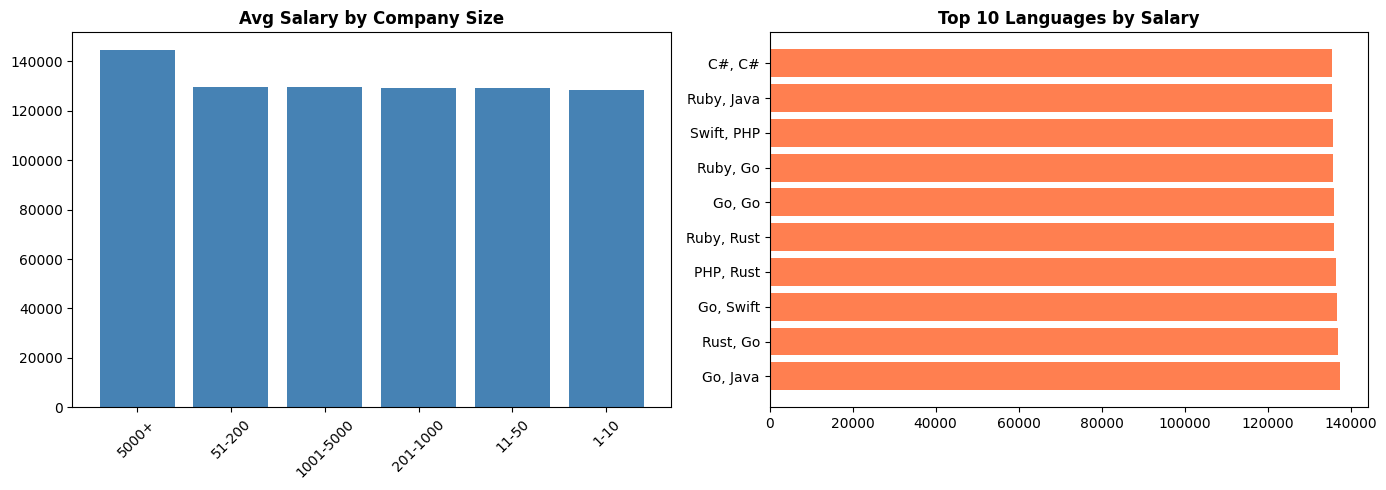

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Company Size vs Salary
size_salary = df.groupby('company_size')['salary_usd'].mean().sort_values(ascending=False)
axes[0].bar(size_salary.index, size_salary.values, color='steelblue')
axes[0].set_title('Avg Salary by Company Size', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Top 10 Languages vs Salary
top_langs = df.groupby('languages')['salary_usd'].mean().sort_values(ascending=False).head(10)
axes[1].barh(top_langs.index, top_langs.values, color='coral')
axes[1].set_title('Top 10 Languages by Salary', fontweight='bold')

plt.tight_layout()
plt.show()

# Insights  
**Company Size:** Bigger companies (5000+) pay slightly more but difference is small — company size doesn’t matter much!  
**Languages:** All top 10 paying around same (~$130K) — language choice doesn’t dramatically change salary. Combinations like C#, Ruby+Java, Swift+PHP top the list.

## 📊 Key Insights — Software Developer Salary EDA

### 1. USA Dominates Global Salaries
USA pays USD155K average — 2x more than India (USD75K).
Location is the single biggest salary factor.

### 2. Experience is the Strongest Predictor
Clear upward trend — every year of experience adds salary.
0 years = USD50K, 40 years = USD250K+

### 3. Education Matters Less Than Expected
PhD earns most but gap between PhD and Bachelors is small.
Skills and experience beat education level.

### 4. Company Size Has Minimal Impact
Large companies (5000+) pay slightly more but difference
is only USD20K across all sizes.

### 5. Programming Language Combinations Matter
Multi-language developers (C#+something, Ruby+Java)
earn more than single language developers.  

note: All Values mention are approx, not absolute values.
